Starting Simulation for TSLA...
Initial Virtual Cash: $100.00

[2010-08-11] BOUGHT 83 shares at $1.19
[2010-09-02] SOLD 83 shares at $1.40
[2010-12-27] BOUGHT 68 shares at $1.70
[2011-01-20] BOUGHT 1 shares at $1.51
[2011-03-31] SOLD 69 shares at $1.85
[2011-08-04] BOUGHT 77 shares at $1.65
[2011-09-16] SOLD 77 shares at $1.72
[2011-12-13] BOUGHT 67 shares at $1.96
[2012-01-13] BOUGHT 1 shares at $1.52
[2012-03-12] SOLD 68 shares at $2.40
[2012-05-08] BOUGHT 81 shares at $2.01
[2012-06-20] SOLD 81 shares at $2.25
[2013-02-21] BOUGHT 77 shares at $2.34
[2013-04-01] SOLD 77 shares at $2.93
[2013-11-06] BOUGHT 22 shares at $10.08
[2014-01-14] SOLD 22 shares at $10.75
[2014-03-24] BOUGHT 16 shares at $14.68
[2014-06-16] SOLD 16 shares at $14.97
[2014-10-10] BOUGHT 15 shares at $15.79
[2014-11-11] SOLD 15 shares at $16.74
[2014-12-08] BOUGHT 18 shares at $14.29
[2015-02-03] SOLD 18 shares at $14.56
[2015-03-27] BOUGHT 21 shares at $12.33
[2015-04-08] SOLD 21 shares at $13.84
[2015-08-06] BO

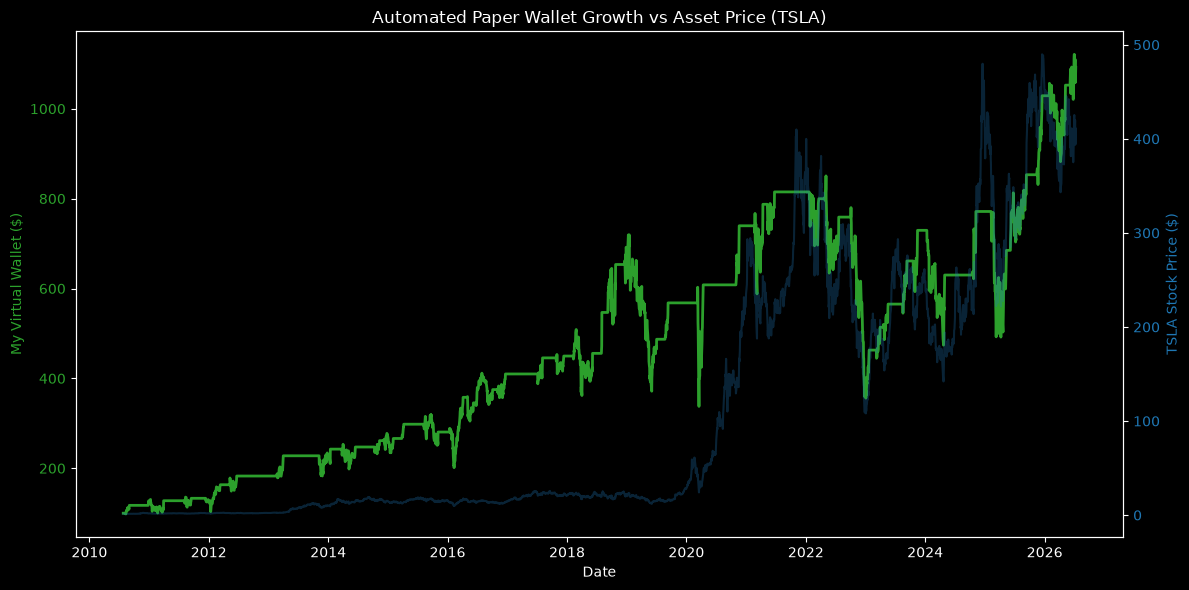

In [14]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

ticker = "TSLA"
initial_balance = 100.0
cash = initial_balance
shares_held = 0
portfolio_history = []

data = yf.download(
    ticker,
    period="20y",
    interval="1d",
    auto_adjust=False,
    multi_level_index=False,
    progress=False
)

if data.empty:
    raise ValueError(f"No stock data was downloaded for {ticker}.")

# Extra protection for yfinance versions that still return MultiIndex columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

period = 20

data["SMA"] = data["Close"].rolling(window=period).mean()
data["STD"] = data["Close"].rolling(window=period).std()
data["Upper_Band"] = data["SMA"] + (data["STD"] * 2)
data["Lower_Band"] = data["SMA"] - (data["STD"] * 2)

data = data.dropna(
    subset=["Close", "SMA", "STD", "Upper_Band", "Lower_Band"]
)

if data.empty:
    raise ValueError("Not enough valid data to calculate the Bollinger Bands.")

print(f"Starting Simulation for {ticker}...")
print(f"Initial Virtual Cash: ${cash:,.2f}\n")

for date, row in data.iterrows():
    current_price = float(row["Close"])
    upper_band = float(row["Upper_Band"])
    lower_band = float(row["Lower_Band"])

    if current_price < lower_band and cash >= current_price:
        shares_to_buy = int(cash // current_price)

        if shares_to_buy > 0:
            cost = shares_to_buy * current_price
            cash -= cost
            shares_held += shares_to_buy

            print(
                f"[{date.strftime('%Y-%m-%d')}] "
                f"BOUGHT {shares_to_buy} shares at ${current_price:.2f}"
            )

    elif current_price > upper_band and shares_held > 0:
        revenue = shares_held * current_price
        cash += revenue

        print(
            f"[{date.strftime('%Y-%m-%d')}] "
            f"SOLD {shares_held} shares at ${current_price:.2f}"
        )

        shares_held = 0

    current_portfolio_value = cash + (shares_held * current_price)

    portfolio_history.append(
        {
            "Date": date,
            "Portfolio_Value": current_portfolio_value,
            "Asset_Price": current_price,
        }
    )

if not portfolio_history:
    raise ValueError("The simulation produced no portfolio history.")

results_df = pd.DataFrame(portfolio_history).set_index("Date")

final_value = float(results_df["Portfolio_Value"].iloc[-1])
total_return = ((final_value - initial_balance) / initial_balance) * 100

print("\n----------------------------------")
print("Simulation Complete!")
print(f"Final Account Balance: ${final_value:,.2f}")
print(f"Total Simulated Return: {total_return:.2f}%")
print("----------------------------------")

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel("Date")
ax1.set_ylabel("My Virtual Wallet ($)", color="tab:green")

ax1.plot(
    results_df.index,
    results_df["Portfolio_Value"],
    color="tab:green",
    linewidth=2,
    label="My Portfolio Value",
)

ax1.tick_params(axis="y", labelcolor="tab:green")

ax2 = ax1.twinx()

ax2.set_ylabel(f"{ticker} Stock Price ($)", color="tab:blue")

ax2.plot(
    results_df.index,
    results_df["Asset_Price"],
    color="tab:blue",
    alpha=0.3,
    label=f"{ticker} Price",
)

ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title(f"Automated Paper Wallet Growth vs Asset Price ({ticker})")
fig.tight_layout()
plt.show()